In [32]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [33]:
"""
Необходимо добавлять путь к библиотеки только в jupyter
"""
from os.path import dirname, abspath
path_library = dirname(abspath(".."))

try:
    from geotechnical_solutions.GeoSimModel.create_models.geology_models import *    # Путь к классу для создания геологии

except ModuleNotFoundError as ex:
    import sys
    sys.path.append(path_library)
    print("Добавление пути к библиотеки geotechnical_solutions")
    from geotechnical_solutions.GeoSimModel.create_models.geology_models import *
     
from geotechnical_solutions.GeoSimModel.create_models.foundation_models import *    # Путь к классу для создания сваи
from geotechnical_solutions.GeoSimModel.solve.building_analysis import *
from geotechnical_solutions.GeoSimModel import path_data    # Получить путь к табличным данным СП (нужно для расчетов)

# Тестовые варианты расчета осадки и ГСТ

In [34]:
def run_gst(DL=None):
    """
    Создание материалов
    """
    for i, ige in enumerate(dict_ige):
        dict_ige[ige] = CreateMaterial()
        dict_ige[ige].change = ("E", E[i])
        dict_ige[ige].change = ("gamma", gamma[i])
    
    """
    Создание скважины
    """
    Borehole_1 = CreateBorehole(0, 0)
    
    """
    Создание слоев в скважине
    """
    for i, soil in enumerate(dict_soil):
        Borehole_1.createSoil(bot=z_soils[i + 1],
                              water=water_soils[i],
                              material=dict_ige[dict_soil[soil]]
                              )
    Borehole_1.change[0][0].change["Top"] = z_soils[0]
    
    """
    Создание нагрузки и плиты
    """
    load_1 = CreateLoad(Type="P", load=P)
    plate_1 = CreatePlate(FL=z_soils[0]-H_found, length=f_length, width=f_width)
    plate_1.change["Load"] = load_1

    """
    Вычисление напряжений
    """
    print(DL)
    if DL is not None:
        Mps = LayerSumMethod(Borehole_1,
                             plate_1,
                             load_1,
                             type_found=found,
                             DL=DL
                             )
    else:
        Mps = LayerSumMethod(Borehole_1,
                             plate_1,
                             load_1,
                             type_found=found,
                             )        
    
    Mps.setting(SP=2, step=0.2, round_value=4)
    Mps.calculation()

    print(f"осадка {Mps.Output()[0]}")
    print(f"ГСТ: {(z_soils[0] - H_found) - Mps.comparison()[0]}")
    print(f"Отметка и номер слоя: {Mps.comparison()}")

    return Mps


def plot_gst(Mps):

    result_dict = Mps.Output()[1]
    
    depth = []
    sigx = []
    sigy = []
    sigz = []
    alpha = []
    
    for key, item in result_dict.items():
        sigx.append(round(item[1]/1000,2))
        sigy.append(round(item[2]/1000,2))
        sigz.append(round(item[3]/1000,2))
        alpha.append(item[4])
        depth.append(float(key))
    
    
    plt.plot(sigx, depth, "-*", label="от грунта ниже FL")
    plt.plot(sigy, depth, "-*", label="Вертикальная нагрузка")
    plt.plot(sigz, depth, "-*", label="от грунта выше FL")
    plt.grid(True)
    plt.legend()
    plt.show()

## Тест 1

In [35]:
"""
Входные данные
"""
counts_ige = 3
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [20e6, 30e6, 40e6]
gamma = [18e3, 19e3, 20e3]
z_soils = [30, 20, 10, 0]
water_soils = [False, False, False]

P = 500e3
H_found = 0
f_length = 2
f_width = 2

found = "прямоугольный"

In [36]:
Mps = run_gst()

None
осадка 0.035254000000000001120
ГСТ: 4.800000000000001
Отметка и номер слоя: (25.2, 0)


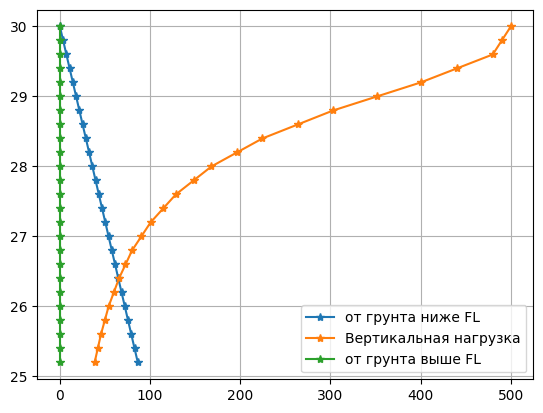

In [37]:
plot_gst(Mps)

## Тест 2

In [38]:
"""
Входные данные
"""
counts_ige = 7
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [11e6, 7e6, 6.1e6, 4.5e6, 6.1e6, 7e6, 11.2e6]
gamma = [17640,
        18522,
        19012,
        19012,
        19012,
        18522,
        19306
        ]
z_soils = [130,
           126.6, 
           125.22, 
           124.12,
           117.62, 
           112.85, 
           104.39, 
           98.3
          ]

water_soils = [False,
               False,
               [123.79, 117.62],
               True,
               True,
               True,
               True
              ]
               

P = 160000
H_found = 0
f_length = 1.4
f_width = 14.3

found = "ленточный"

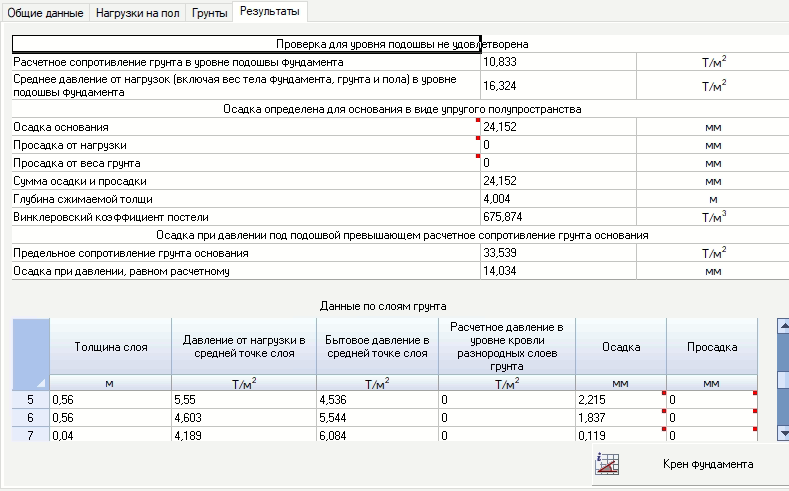

In [39]:
Mps = run_gst()

None
осадка 0.3357886534263352141190433613
ГСТ: 12.379999999999995
Отметка и номер слоя: (117.62, 3)


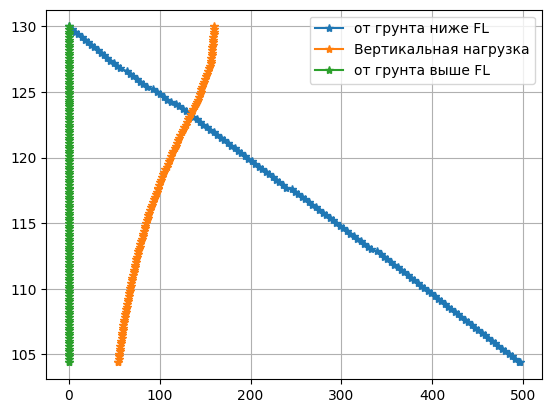

In [40]:
plot_gst(Mps)

## Тест 3

None
осадка 1.243126857142857109790476192
ГСТ: 16.700000000000003
Отметка и номер слоя: (113.3, 2)


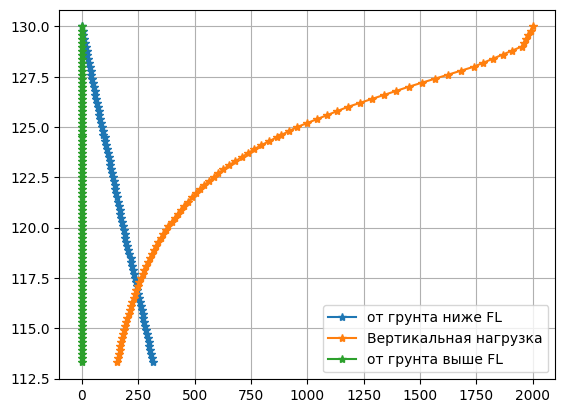

In [41]:
counts_ige = 4
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [7e6, 12e6, 8e6, 10e6]
gamma = [17640,
        18522,
        19012,
        19012,
        ]
z_soils = [130,
           124.5, 
           124.5 - 6, 
           124.5 - 6 - 6.5,
           124.5 - 6 - 6.5 - 7, 
          ]

water_soils = [False,
               False,
               False,
               False,
              ]
               

P = 2e6
H_found = 0
f_length = 10
f_width = 5

found = "прямоугольный"

Mps = run_gst()
plot_gst(Mps)

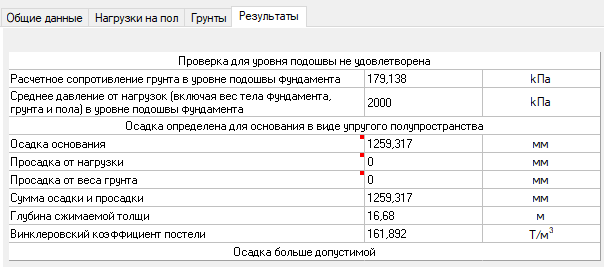
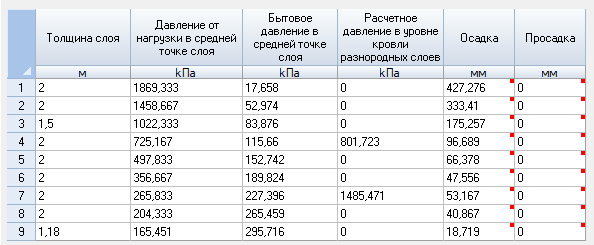

## Тест 4

125
осадка 0.06353983999999999880000000003
ГСТ: 6.900000000000006
Отметка и номер слоя: (118.1, 2)


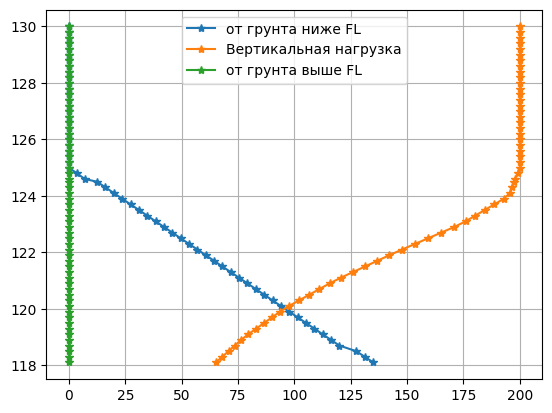

In [42]:
counts_ige = 4
dict_ige = {}
dict_soil = {}


for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"


E = [10e6, 12e6, 8e6, 10e6]
gamma = [17640,
        18522,
        19012,
        19012,
        ]
z_soils = [130,
           124.5, 
           124.5 - 6, 
           124.5 - 6 - 6.5,
           124.5 - 6 - 6.5 - 7, 
          ]

water_soils = [False,
               False,
               False,
               False,
              ]


P = 2e5
H_found = 5
DL = 130 - H_found
f_length = 10
f_width = 5

found = "прямоугольный"

Mps = run_gst(DL=DL)
plot_gst(Mps)

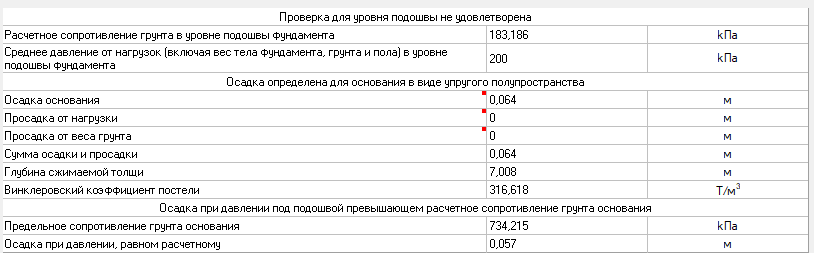
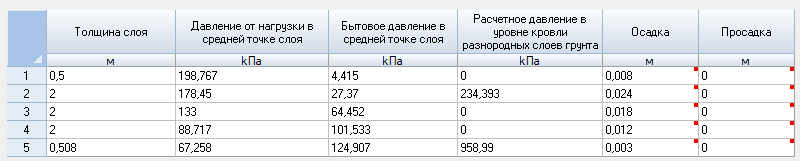

## Тест 5

130
осадка 0.10243000608000000023200
ГСТ: 6.0
Отметка и номер слоя: (119.0, 2)


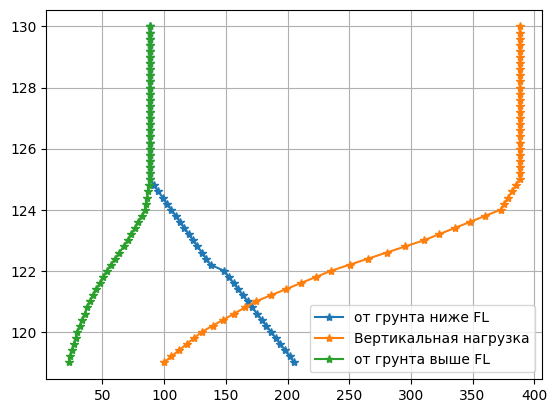

In [63]:
counts_ige = 4
dict_ige = {}
dict_soil = {}


for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"


E = [10e6, 12e6, 8e6, 10e6]
gamma = [17640,
        18522,
        19012,
        19012,
        ]
z_soils = [130,
           130 - 8, 
           130 - 8,- 6, 
           130 - 8,- 6 - 6.5,
           130 - 8,- 6 - 6.5 - 7, 
          ]

water_soils = [False,
               False,
               False,
               False,
              ]


P = 3e5
H_found = 5
DL = 130
f_length = 5
f_width = 5

found = "прямоугольный"

Mps = run_gst(DL=DL)
plot_gst(Mps)

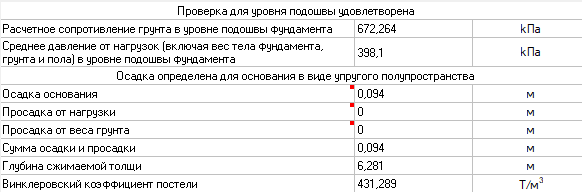
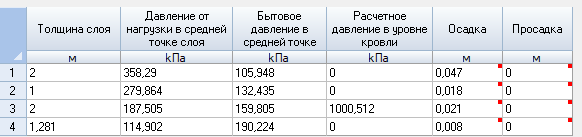

In [64]:
result_dict = Mps.Output()[1]
depth = []
sigx = []
sigy = []
sigz = []
alpha = []

for key, item in result_dict.items():
    sigx.append(round(item[1]/1000,2))
    sigy.append(round(item[2]/1000,2))
    sigz.append(round(item[3]/1000,2))
    alpha.append(item[4])
    depth.append(float(key))

sigx = np.array(sigx)
sigy = np.array(sigy)
sigz = np.array(sigz)
depth = np.array(depth)
alpha = np.array(alpha)

In [65]:
np.where(sigx <= sigz)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25]),)

In [70]:
depth[25:]

array([125. , 124.8, 124.6, 124.4, 124.2, 124. , 123.8, 123.6, 123.4,
       123.2, 123. , 122.8, 122.6, 122.4, 122.2, 122. , 121.8, 121.6,
       121.4, 121.2, 121. , 120.8, 120.6, 120.4, 120.2, 120. , 119.8,
       119.6, 119.4, 119.2, 119. ])

In [71]:
sigx[25:]*.5

array([ 44.1  ,  45.865,  47.63 ,  49.39 ,  51.155,  52.92 ,  54.685,
        56.45 ,  58.21 ,  59.975,  61.74 ,  63.505,  65.27 ,  67.03 ,
        68.795,  74.315,  76.215,  78.115,  80.015,  81.92 ,  83.82 ,
        85.72 ,  87.62 ,  89.525,  91.425,  93.325,  95.225,  97.13 ,
        99.03 , 100.93 , 102.83 ])

In [72]:
sigy[25:]

array([388.2 , 385.09, 381.99, 378.88, 375.78, 372.67, 360.25, 347.83,
       335.4 , 322.98, 310.56, 295.5 , 280.44, 265.37, 250.31, 235.25,
       223.06, 210.87, 198.68, 186.49, 174.3 , 165.53, 156.76, 147.98,
       139.21, 130.44, 124.3 , 118.17, 112.03, 105.9 ,  99.77])

## Другое

In [49]:
df_alpha = pd.read_excel(r'alpha.xlsx')
matrix = df_alpha.applymap(lambda x: float(str(x).replace(',', '.'))).to_numpy()

nu = 1
eps = 6.8


if nu >= 10:
    found='прямоугольный'

columns = ['eps', 'cycle', 1, 1.4, 1.8, 2.4, 3.2, 5, 'strip']

def interpol_alpha(eps, 
                   nu, 
                   type_found='прямоугольный'
                  ):
    
    eps_arr = matrix[:, 0]

    left = np.where((eps_arr <= eps))[0][-1]
    right = np.where((eps_arr >= eps))[0][0]

    if left == right:
        row_result = matrix[left, :]

    else:
        row_l = matrix[left, :]
        row_r = matrix[right, :]
        
        row_result = (row_r - row_l)/(row_r[0] - row_l[0]) * (eps - row_l[0]) + row_l
    
    if type_found == 'круглый':
        return row_result[1]
    
    if nu >= 10 or type_found == 'ленточный':
        return row_result[-1]

    nu_arr = np.array([1, 1.4, 1.8, 2.4, 3.2, 5, 10])
    left = np.where((nu_arr <= nu))[0][-1] + 2
    right = np.where((nu_arr >= nu))[0][0] + 2

    if nu_arr[left - 2] == nu_arr[right - 2]:
        return row_result[left]

    return (row_result[right] - row_result[left])/(nu_arr[right - 2] - nu_arr[left - 2]) * (nu - nu_arr[left - 2]) + row_result[left]
    
interpol_alpha(eps, nu)

C:\Users\lix96\AppData\Local\Temp\ipykernel_14204\1319037209.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = df_alpha.applymap(lambda x: float(str(x).replace(',', '.'))).to_numpy()


np.float64(0.04)

In [50]:
#z_list = [130, 124.5, 123.5, 116.3, 104.3]

z_list = [130,
           126.6, 
           125.2, 
           123.8,
           117.6, 
           112.8, 
           104.4, 
           98.3
          ]

def interpol_alpha(eps, 
                   nu, 
                   type_found='прямоугольный'
                  ):
    
    eps_arr = matrix[:, 0]

    left = np.where((eps_arr <= eps))[0][-1]
    right = np.where((eps_arr >= eps))[0][0]

    if left == right:
        row_result = matrix[left, :]

    else:
        row_l = matrix[left, :]
        row_r = matrix[right, :]
        
        row_result = (row_r - row_l)/(row_r[0] - row_l[0]) * (eps - row_l[0]) + row_l
    
    if type_found == 'круглый':
        return row_result[1]
    
    if nu >= 10 or type_found == 'ленточный':
        return row_result[-1]

    nu_arr = np.array([1, 1.4, 1.8, 2.4, 3.2, 5, 10])
    left = np.where((nu_arr <= nu))[0][-1] + 2
    right = np.where((nu_arr >= nu))[0][0] + 2

    if nu_arr[left - 2] == nu_arr[right - 2]:
        return row_result[left]

    return (row_result[right] - row_result[left])/(nu_arr[right - 2] - nu_arr[left - 2]) * (nu - nu_arr[left - 2]) + row_result[left]

def get_interval(z_list, step=.1):

    def get_count(num):
        x = num/step
        y = num//step
        if x - y >= .5:
           y+=1 
        return int(y)
    
    depth_all = np.array([0])
    z_depth = z_list[0] - np.array(z_list)

    for i in range(1, len(z_depth)):
        before = z_depth[i-1]
        after = z_depth[i]
        count = get_count(after - before)
        interval = np.linspace(before + step, after, count)
        
        depth_all = np.append(depth_all, interval)

    return depth_all

def get_interval_alpha(eps_list, nu, type_found='прямоугольный'):
    result = []
    for eps in eps_list:
        result.append(interpol_alpha(eps, nu, type_found))

    return np.array(result)


def get_sigzp(P, interval, nu, b):

    eps_list = 2 * interval / b

    alpha_list = get_interval_alpha(eps_list, nu)
    return alpha_list*P


def get_sigzg(interval, nu, b):

    eps_list = 2 * interval / b

    alpha_list = get_interval_alpha(eps_list, nu)
    return alpha_list*P


nu=11
b = 14.3

found = "ленточный"
sigzp = get_sigzp(160, get_interval(z_list), nu, b)
hi = get_interval(z_list)
hi

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
       13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
       14.3, 14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15

In [51]:
nu_list = [1, 1.4, 1.8, 2.4, 3.2, 5, 10]

columns = ['eps', 'cycle', 1, 1.4, 1.8, 2.4, 3.2, 5, 'strip']

matrix = []

with open('alpha.txt', "r", encoding="utf-8") as f:
    for row, text in enumerate(f.readlines()):
        eps = round(0.4 * row, 1)
        text_list = text.split()
        
        text_list = list(map(lambda x: float(x.replace(',', '.')), text_list))

        matrix.append(text_list)

matrix = np.array(matrix)

nu = 3
eps = 1.4

interpol_alpha(eps, nu)

np.float64(0.685625)

In [52]:
"""
Входные данные
"""
counts_ige = 7
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [11e6, 
     7e6, 
     6.1e6, 
     4.5e6, 
     6.1e6, 
     7e6, 
     11.2e6
    ]
gamma = [17640,
        18522,
        19012,
        19012,
        19012,
        18522,
        19306
        ]
z_list = [130,
           126.6, 
           125.2, 
           123.8,
           117.6, 
           112.8, 
           104.4, 
           98.3
          ]

water_soils = [False,
               False,
               False,
               False,
               False,
               False,
               False
              ]
               

P = 160000
H_found = 0
f_length = 1.4
f_width = 14.3

found = "ленточный"

In [53]:
"""
Создание материалов
"""
for i, ige in enumerate(dict_ige):
    dict_ige[ige] = CreateMaterial()
    dict_ige[ige].change = ("E", E[i])
    dict_ige[ige].change = ("gamma", gamma[i])

"""
Создание скважины
"""
Borehole_1 = CreateBorehole(0, 0)

"""
Создание слоев в скважине
"""
for i, soil in enumerate(dict_soil):
    Borehole_1.createSoil(bot=z_soils[i + 1],
                          water=water_soils[i],
                          material=dict_ige[dict_soil[soil]]
                          )
Borehole_1.change[0][0].change["Top"] = z_soils[0]

"""
Создание нагрузки и плиты
"""
load_1 = CreateLoad(Type="P", load=P)
plate_1 = CreatePlate(FL=z_soils[0]-H_found, length=f_length, width=f_width)
plate_1.change["Load"] = load_1

In [54]:
"""
Вычисление напряжений
"""
Mps = LayerSumMethod(Borehole_1,
                     plate_1,
                     load_1,
                     type_found=found,
                     path_alpha = path_data+r"alpha.txt"
                     )

#Mps.round_value = 1

Mps.setting(step=.1, round_value=2)
Mps.calculation()

In [55]:
print(f"осадка {Mps.Output()[0]}")
print(f"ГСТ: {(z_soils[0] - H_found) - Mps.comparison()[0]}")
print(f"Отметка и номер слоя: {Mps.comparison()}")

осадка 0.1152624213604577247999999999
ГСТ: 11.599999999999994
Отметка и номер слоя: (118.4, 0)


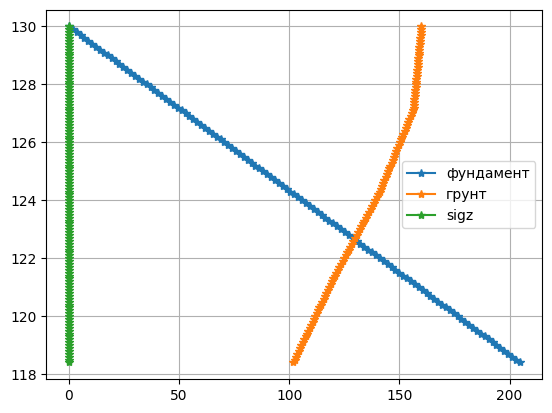

In [56]:
result_dict = Mps.Output()[1]
depth = []
sigx = []
sigy = []
sigz = []
alpha = []

for key, item in result_dict.items():
    sigx.append(round(item[1]/1000,2))
    sigy.append(round(item[2]/1000,2))
    sigz.append(round(item[3]/1000,2))
    alpha.append(item[4])
    depth.append(float(key))


plt.plot(sigx, depth, "-*", label="фундамент")
plt.plot(sigy, depth, "-*", label="грунт")
plt.plot(sigz, depth, "-*", label="sigz")
plt.grid(True)
plt.legend()
plt.show()

In [57]:
import numpy as np
sigx = np.array(sigx)
sigy = np.array(sigy)
depth = np.array(depth)
alpha = np.array(alpha)

In [58]:
alpha

array([1.        , 0.9991958 , 0.99839161, 0.99758741, 0.99678322,
       0.99597902, 0.99517483, 0.99437063, 0.99356643, 0.99276224,
       0.99195804, 0.99115385, 0.99034965, 0.98954545, 0.98874126,
       0.98793706, 0.98713287, 0.98632867, 0.98552448, 0.98472028,
       0.98391608, 0.98311189, 0.98230769, 0.9815035 , 0.9806993 ,
       0.9798951 , 0.97909091, 0.97828671, 0.97748252, 0.97565734,
       0.9723007 , 0.96894406, 0.96558741, 0.96223077, 0.95887413,
       0.95551748, 0.95216084, 0.9488042 , 0.94544755, 0.94209091,
       0.93873427, 0.93537762, 0.93202098, 0.92866434, 0.92530769,
       0.92195105, 0.91859441, 0.91523776, 0.91188112, 0.90852448,
       0.90516783, 0.90181119, 0.89845455, 0.8950979 , 0.89174126,
       0.88838462, 0.88502797, 0.88167133, 0.87747552, 0.87306993,
       0.86866434, 0.86425874, 0.85985315, 0.85544755, 0.85104196,
       0.84663636, 0.84223077, 0.83782517, 0.83341958, 0.82901399,
       0.82460839, 0.8202028 , 0.8157972 , 0.81139161, 0.80698

In [59]:
-depth[65:70]+130

array([6.5, 6.6, 6.7, 6.8, 6.9])

In [60]:
hi.shape, depth.shape

((318,), (117,))

In [61]:
np.where(depth[:-1] - depth[1:] < .09)

(array([], dtype=int64),)

In [62]:
-depth[[ 34, 35,  49, 50,  64, 65, 127,128, 176,177]]+130

IndexError: index 127 is out of bounds for axis 0 with size 117

In [ ]:
hi[[ 34, 35,  49, 50,  64, 65, 127,128, 176,177]]

In [ ]:
sigy[65:70]

In [ ]:
sigzp[65:70]

In [ ]:
from decimal import Decimal

x = 0.0

step = 0.01
error = 0.0

y = Decimal('0.0')

for _ in range(100):
    # Корректируем шаг с учётом накопленной ошибки
    new_x = x + (step + error)
    error = (x - new_x) + (step + error)  # Корректируем ошибку
    x = new_x
    y+=Decimal('0.01')
    
    print(y, x)